# Импорты и загрузка данных

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# -----------------------
# Загрузка данных
# -----------------------
data_path = "S05-hw-dataset.csv"
df = pd.read_csv(data_path)

display(df.head())
df.info()
df.describe()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


# Анализ таргета

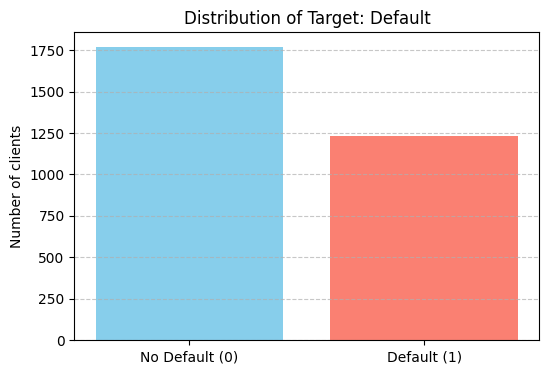

In [73]:
counts = df["default"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])
plt.xticks([0,1], ['No Default (0)', 'Default (1)'])
plt.ylabel('Number of clients')
plt.title('Distribution of Target: Default')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Подготовка признаков и таргета

In [74]:
X = df.drop(columns=["client_id", "default"])
y = df["default"]

# Train/Test сплит

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2400, 15)
Test size: (600, 15)


# Бейзлайн-модель (DummyClassifier)

In [76]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy_pred = dummy.predict(X_test)
y_dummy_proba = dummy.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_dummy_pred)
roc_dummy = roc_auc_score(y_test, y_dummy_proba)

print("Dummy Accuracy:", acc_dummy)
print("Dummy ROC-AUC:", roc_dummy)


Dummy Accuracy: 0.59
Dummy ROC-AUC: 0.5


# Логистическая регрессия через Pipeline и GridSearchCV

In [77]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

param_grid = {"logreg__C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best C:", grid.best_params_)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print("LogReg Accuracy:", acc)
print("LogReg ROC-AUC:", roc)

Best C: {'logreg__C': 10}
LogReg Accuracy: 0.8
LogReg ROC-AUC: 0.8756373156951908


# Сравнение моделей

In [78]:
results = pd.DataFrame({
    "Model": ["DummyClassifier", "LogisticRegression"],
    "Accuracy": [acc_dummy, acc],
    "ROC-AUC": [roc_dummy, roc]
})
print(results)


                Model  Accuracy   ROC-AUC
0     DummyClassifier      0.59  0.500000
1  LogisticRegression      0.80  0.875637


# ROC-график

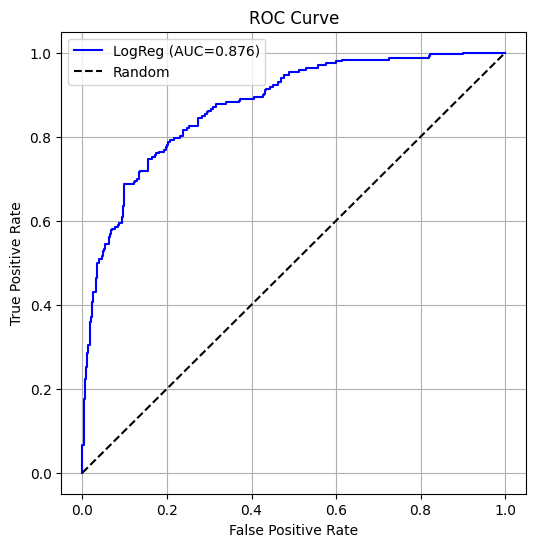

In [79]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'LogReg (AUC={roc:.3f})', color='blue')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


# Confusion Matrix

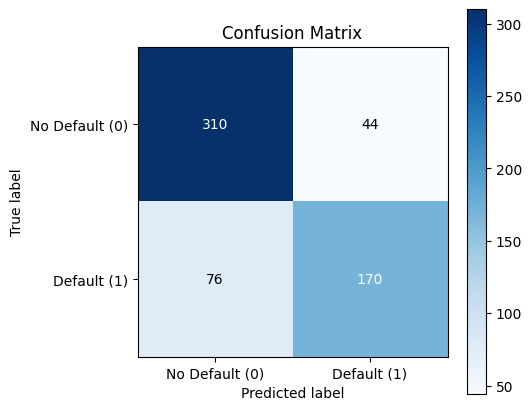

In [80]:
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    return np.array([[tn, fp],
                     [fn, tp]])

cm = confusion_matrix_manual(y_test.values, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['No Default (0)','Default (1)'])
plt.yticks([0,1], ['No Default (0)','Default (1)'])
thresh = cm.max()/2
for i in range(2):
    for j in range(2):
        plt.text(j,i, cm[i,j], ha='center', va='center', 
                 color='white' if cm[i,j]>thresh else 'black')
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

## Выводы

В качестве бейзлайн-модели был использован DummyClassifier, который предсказывает
наиболее частый класс. Его accuracy составила **0.59**, а ROC-AUC оказался равен
**0.50**, что соответствует качеству, близкому к случайному угадыванию.

Логистическая регрессия со стандартизацией признаков показала существенно более
высокое качество. После подбора коэффициента регуляризации C с помощью GridSearchCV
accuracy выросла до **0.80**, а ROC-AUC — до **0.876**.

Таким образом, логистическая регрессия значительно превосходит бейзлайн по обеим
ключевым метрикам и является разумной моделью для данной задачи бинарной
классификации.

